In [44]:


import pandas as pd # type: ignore
import numpy as np # type: ignore
import matplotlib.pyplot as plt # pyright: ignore[reportMissingModuleSource]
%matplotlib inline

In [45]:
# Dataset source
data_url = "http://lib.stat.cmu.edu/datasets/boston"

# Load raw data
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)

# Fix the structure: features are split across two rows
X = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
y = raw_df.values[1::2, 2]

# Column names
feature_names = [
    "CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM",
    "AGE", "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT"
]

# Create DataFrame
dataset= pd.DataFrame(X, columns=feature_names)

dataset.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33


In [46]:
dataset["Price"] = y   # Price = target (Median value of owner-occupied homes)
dataset.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Price
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [47]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  Price    506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB


In [48]:
## Summarizing the stats
dataset.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Price
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [49]:
#Check the Missing Values
dataset.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
Price      0
dtype: int64

In [50]:
### Exploratory Data Analysis
## Correlation
dataset.corr()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Price
CRIM,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
ZN,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
INDUS,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
CHAS,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
NOX,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
RM,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
AGE,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
DIS,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
RAD,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626
TAX,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536


Text(0, 0.5, 'Price')

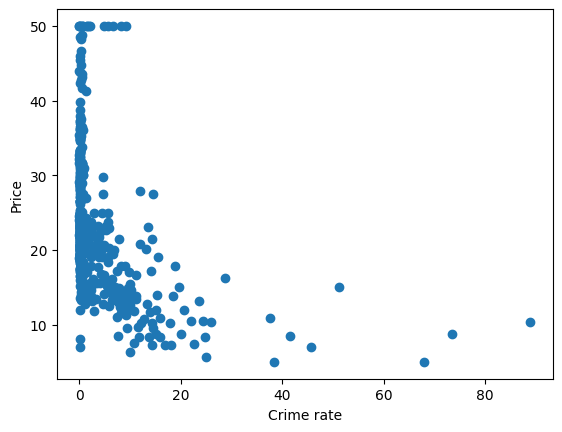

In [51]:
plt.scatter(dataset['CRIM'],dataset['Price'])
plt.xlabel("Crime rate")
plt.ylabel("Price")

<Axes: xlabel='RM', ylabel='Price'>

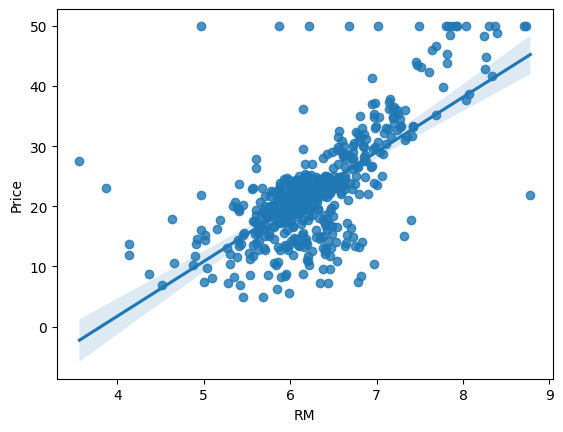

In [52]:
import seaborn as sns # type: ignore
sns.regplot(x="RM",y="Price",data=dataset)

<Axes: xlabel='LSTAT', ylabel='Price'>

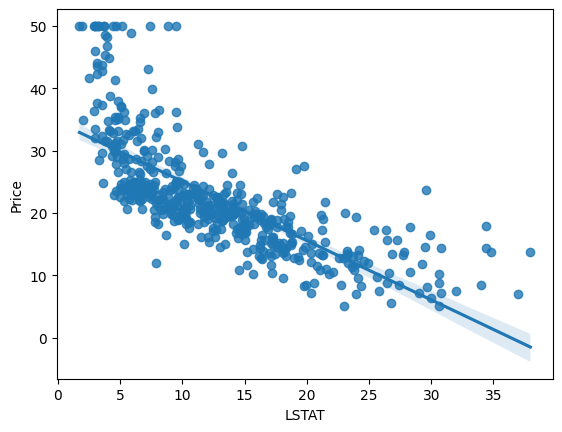

In [53]:
sns.regplot(x="LSTAT",y="Price",data=dataset)

<Axes: xlabel='CHAS', ylabel='Price'>

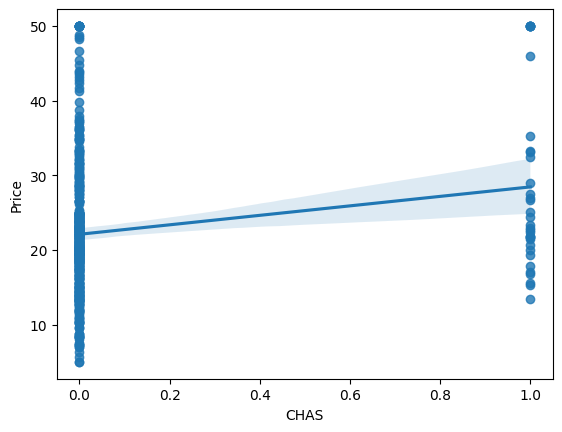

In [54]:
sns.regplot(x="CHAS",y="Price",data=dataset)

<Axes: xlabel='PTRATIO', ylabel='Price'>

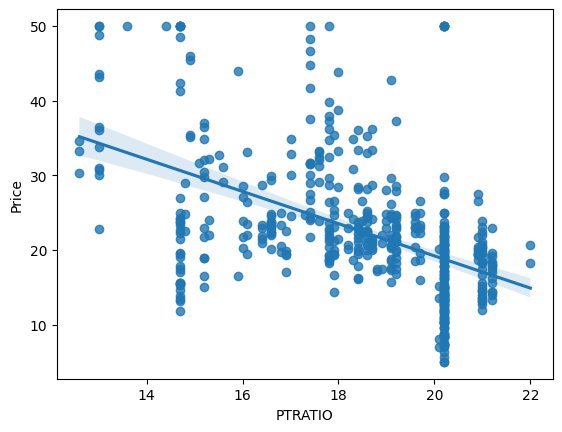

In [55]:
sns.regplot(x="PTRATIO",y="Price",data=dataset)

In [56]:
## Independent and Dependent features
X=dataset.iloc[:,:-1]
y=dataset.iloc[:,-1]

In [57]:
X.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33


In [58]:
y.head()

0    24.0
1    21.6
2    34.7
3    33.4
4    36.2
Name: Price, dtype: float64

In [59]:
## Train Test Split
from sklearn.model_selection import train_test_split # type: ignore
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [60]:
X_train.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
5,0.02985,0.0,2.18,0.0,0.458,6.430,58.7,6.0622,3.0,222.0,18.7,394.12,5.21
116,0.13158,0.0,10.01,0.0,0.547,6.176,72.5,2.7301,6.0,432.0,17.8,393.30,12.04
45,0.17142,0.0,6.91,0.0,0.448,5.682,33.8,5.1004,3.0,233.0,17.9,396.90,10.21
16,1.05393,0.0,8.14,0.0,0.538,5.935,29.3,4.4986,4.0,307.0,21.0,386.85,6.58
468,15.57570,0.0,18.10,0.0,0.580,5.926,71.0,2.9084,24.0,666.0,20.2,368.74,18.13


In [61]:
## Standardize the dataset
from sklearn.preprocessing import StandardScaler # type: ignore
scaler=StandardScaler()


In [62]:
X_train=scaler.fit_transform(X_train)

In [63]:
X_train

array([[-0.41425879, -0.50512499, -1.29214218, ...,  0.18727079,
         0.39651419, -1.01531611],
       [-0.40200818, -0.50512499, -0.16208345, ..., -0.21208981,
         0.3870674 , -0.05366252],
       [-0.39721053, -0.50512499, -0.60948856, ..., -0.16771641,
         0.42854113, -0.31132373],
       ...,
       [-0.41604586,  3.03838247, -1.3166773 , ..., -0.56707702,
         0.35987906, -0.90549329],
       [ 0.92611293, -0.50512499,  1.00549958, ...,  0.8528718 ,
        -2.87841346,  1.52750437],
       [-0.39030549, -0.50512499, -0.37135358, ...,  1.16348561,
        -3.32828832, -0.25218837]])

In [64]:
X_test=scaler.transform(X_test)

In [65]:
X_test

array([[-0.406801  , -0.50512499, -1.02225586, ..., -0.74457062,
         0.41241246, -0.47605794],
       [-0.41105674,  1.26662874, -0.68165068, ..., -0.30083661,
         0.42854113, -1.25185755],
       [-0.4051199 , -0.50512499,  2.39678516, ...,  0.8084984 ,
         0.35031705,  0.79535229],
       ...,
       [-0.35439903, -0.50512499, -0.71195877, ..., -0.38958342,
         0.25688594, -1.09697922],
       [ 0.25423453, -0.50512499,  1.00549958, ...,  0.8528718 ,
        -2.98970133,  0.53487511],
       [ 0.77732457, -0.50512499,  1.00549958, ...,  0.8528718 ,
         0.33199949,  0.56585078]])

# Model Training

In [66]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error

models = {
    'Linear Regression': LinearRegression(),
    'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=42),
    'Random Forest Regressor': RandomForestRegressor(random_state=42),
    'Support Vector Regressor': SVR(),
    'K-Nearest Neighbors Regressor': KNeighborsRegressor(),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42)
}

results = {}
for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Evaluate the model
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    results[name] = {'R-squared': r2, 'Mean Squared Error': mse}
    print(f"{name};")
    print(f"R-squared: {r2:.4f}")
    print(f"Mean Squared Error: {mse:.4f}\n")

# Find the best model based on R-squared score
best_model_name = max(results, key=lambda name: results[name]['R-squared'])
print(f"The best performing model is: {best_model_name}")

# You can now save the best model for future use
best_model = models[best_model_name]

Linear Regression;
R-squared: 0.7112
Mean Squared Error: 21.5174

Gradient Boosting Regressor;
R-squared: 0.8909
Mean Squared Error: 8.1316

Random Forest Regressor;
R-squared: 0.8709
Mean Squared Error: 9.6219

Support Vector Regressor;
R-squared: 0.6516
Mean Squared Error: 25.9572

K-Nearest Neighbors Regressor;
R-squared: 0.7472
Mean Squared Error: 18.8350

Decision Tree Regressor;
R-squared: 0.8442
Mean Squared Error: 11.6091

The best performing model is: Gradient Boosting Regressor


In [67]:
### Prediction with Test Data
reg_pred=best_model.predict(X_test)

In [68]:
reg_pred

array([23.00027395, 31.04169623, 16.3600042 , 23.53704333, 17.59742873,
       22.11977618, 18.33305944, 14.07230519, 20.72818075, 21.0787828 ,
       20.56035828, 18.57567075,  7.4994262 , 21.55967925, 20.61412792,
       24.77944939, 18.90158454,  8.87350633, 45.45073897, 16.98843693,
       24.36990385, 25.55054385, 13.95009685, 21.51629555, 15.37001689,
       16.95721664, 22.08662665, 13.78873174, 19.99785295, 21.30511162,
       19.52663102, 23.77395504, 21.00232411, 20.20000596, 14.54348757,
       16.57110933, 33.51682874, 19.50945461, 21.43628896, 24.00658511,
       18.3184668 , 30.77320162, 44.12089923, 20.62571914, 22.41735907,
       14.77300932, 16.59420397, 24.06753956, 18.31435252, 27.98195113,
       20.63603742, 37.63998564, 17.16556573, 24.7223098 , 46.73697291,
       21.26208745, 15.77077976, 32.22413616, 22.16579526, 18.85723217,
       22.34305191, 33.24627309, 30.49174498, 19.870745  , 23.92594617,
       18.25387872, 15.04151927, 23.84374236, 28.92788266, 15.48

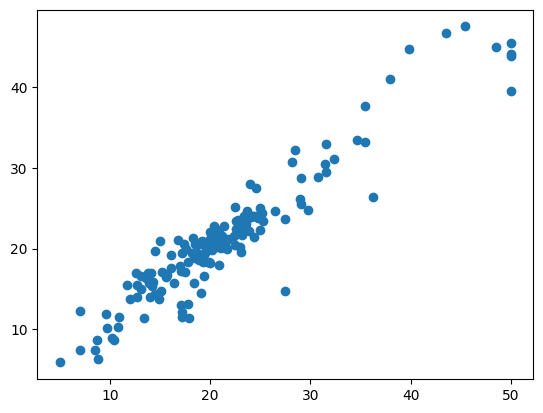

In [69]:
## plot a scatter plot for the prediction
plt.scatter(y_test,reg_pred)

In [70]:
##Residuals
residuals=y_test-reg_pred

In [71]:
residuals

173    0.599726
274    1.358304
491   -2.760004
72    -0.737043
452   -1.497429
         ...   
441    4.039567
23     0.123628
225    6.124489
433   -1.597981
447   -4.381162
Name: Price, Length: 152, dtype: float64

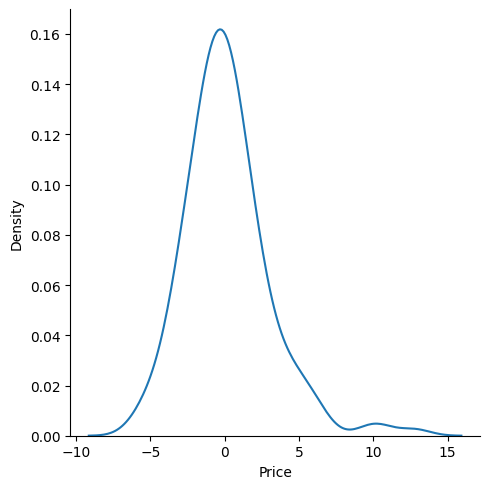

In [72]:
## Plot this Residuals
sns.displot(residuals,kind="kde")

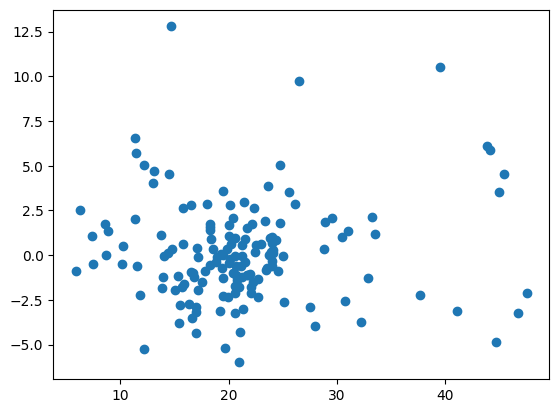

In [73]:
## Scatter plot with respect to prediction and residuals
plt.scatter(reg_pred,residuals)

In [74]:
from sklearn.metrics import mean_squared_error,mean_absolute_error # type: ignore

print(mean_absolute_error(y_test,reg_pred))
print(mean_squared_error(y_test,reg_pred))
print(np.sqrt(mean_squared_error(y_test,reg_pred)))



2.0517796678535554
8.131551535841314
2.8515875465854656


# R square and adjusted R square

In [75]:
from sklearn.metrics import r2_score # type: ignore
score=r2_score(y_test,reg_pred)
print(score)

0.8908708398990747


In [76]:
#display adjusted R-squared
1-(1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.8805905567011614

# Pickling The Model file For Deployment

In [77]:
import pickle

In [ ]:
pickle.dump(regression,open('regmodel.pkl','wb'))

In [79]:
pickled_model=pickle.load(open('regmodel.pkl','rb'))

In [80]:
## Prediction
pickled_model.predict(
    scaler.transform(X.iloc[0].values.reshape(1, -1))
)


c:\Users\SRI CHARAN SAI TEJA\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([30.08649576])

In [81]:
import pickle
pickle.dump(scaler, open('scaler.pkl', 'wb'))

### Note on Target Variable
- The predicted **Price** is the median value of owner-occupied homes in **thousands of dollars (USD)**.
- For example, a predicted value of `20` means $20,000.